In [39]:
import pandas as pd
greylock = pd.read_csv("../data-collection/greylock_portfolio.csv")
greylock = greylock[~greylock['website'].isna()]
yc = pd.read_csv("../data-collection/archive_1/yc_companies.csv")
yc.drop_duplicates(subset='name', inplace=True)
yc = yc[yc['website'] != 'http://']
yc = yc[~yc['website'].isna()]
merge = pd.merge(greylock, yc, on='website', how='inner')
merge.value_counts("name_x")

name_x
docker     1
dropbox    1
ramp       1
sqreen     1
vori       1
Name: count, dtype: int64

In [112]:
yc[yc['batch'] == 'Winter 2026']

,slug,name,batch,status,industry,subindustry,one_liner,team_size,stage,top_company,...,hn_points,hn_comments,total_funding_usd,last_funding_round,acquired_by,ipo_date,is_dead,website,yc_url,founders
5558,10x-science,10x Science,Winter 2026,Active,B2B,B2B,The AI-native platform for next-generation pro...,3.0,Early,0,...,157.0,33.0,NaN,NaN,NaN,NaN,NaN,https://10xscience.com,https://www.ycombinator.com/companies/10x-science,NaN
5559,1code-21stdev,1code (21st.dev),Winter 2026,Active,B2B,"B2B -> Engineering, Product and Design",Orchestration layer for coding agents,3.0,Early,0,...,75.0,49.0,NaN,NaN,NaN,NaN,NaN,https://1code.dev,https://www.ycombinator.com/companies/1code-21...,NaN
5560,arc-prize-foundation,ARC Prize Foundation,Winter 2026,Active,Industrials,Industrials,AI benchmarks that measure general intelligenc...,4.0,Early,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://arcprize.org/,https://www.ycombinator.com/companies/arc-priz...,NaN
5561,arcline,Arcline,Winter 2026,Active,B2B,B2B -> Legal,Startup legal work handled by elite lawyers & ...,5.0,Early,0,...,1.0,0.0,NaN,NaN,NaN,NaN,NaN,https://www.arcline-ai.com/,https://www.ycombinator.com/companies/arcline,NaN
5562,arzule,Arzule,Winter 2026,Active,B2B,B2B,AI for B2B Partnership Intelligence,2.0,Early,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.arzule.com,https://www.ycombinator.com/companies/arzule,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5685,voxel-energy,Voxel Energy,Winter 2026,Active,Industrials,Industrials -> Energy,Energy independent data centers with solar and...,3.0,Early,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://voxelenergy.com/,https://www.ycombinator.com/companies/voxel-en...,NaN
5686,zerosettle,ZeroSettle,Winter 2026,Active,B2B,B2B -> Sales,Bypass the App Store tax and enable web-based ...,2.0,Early,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://zerosettle.io,https://www.ycombinator.com/companies/zerosettle,NaN
5687,zymbly,Zymbly,Winter 2026,Active,B2B,B2B,Automates admin for aircraft technicians,0.0,Early,0,...,6.0,8.0,NaN,NaN,NaN,NaN,NaN,https://www.zymbly.com,https://www.ycombinator.com/companies/zymbly,NaN
5688,o11,o11,Winter 2026,Active,B2B,B2B -> Finance and Accounting,The Most Integrated M365 AI Suite,4.0,Early,0,...,174.0,58.0,NaN,NaN,NaN,NaN,NaN,https://o11.ai,https://www.ycombinator.com/companies/o11,NaN


In [99]:
greylock.value_counts("domain")

def get_multilabel_counts(series):
    """
    Splits comma-separated strings and returns a clean value_counts
    for individual attributes.
    """
    # Split by comma, strip whitespace, and expand into a list
    split_series = series.str.split(',').apply(lambda x: [i.strip() for i in x])
    
    # Flatten the list and count occurrences
    exploded_counts = split_series.explode().value_counts()
    return exploded_counts

# Usage:
# counts = get_multilabel_counts(df['domain'])


def apply_taxonomy(series):
    taxonomy = {
        # Parent Bucket : [List of tags that belong to it]
        'AI': ['AI', 'AI, Infrastructure', 'AI, SaaS', 'AI, Cybersecurity', 
               'AI, Marketplace & Commerce', 'AI, Fintech & Crypto', 'AI, Consumer'],
        'SaaS': ['SaaS'],
        'Cybersecurity': ['Cybersecurity', 'Cybersecurity, Infrastructure'],
        'Fintech & Crypto': ['Fintech & Crypto', 'Consumer, Fintech & Crypto', 
                             'Fintech & Crypto, SaaS', 'Fintech & Crypto, Marketplace & Commerce'],
        'Infrastructure': ['Infrastructure', 'Infrastructure, Marketplace & Commerce, SaaS'],
        'Marketplace & Commerce': ['Marketplace & Commerce', 'Consumer, Marketplace & Commerce', 
                                    'Marketplace & Commerce, SaaS', 'Consumer, Marketplace & Commerce, SaaS'],
        'Consumer': ['Consumer']
    }
    
    # Inverse the dictionary for mapping
    mapping = {child: parent for parent, children in taxonomy.items() for child in children}
    
    return series.map(mapping).fillna('Other')

# Usage:
df['broad_domain'] = apply_taxonomy(greylock['domain'])
new_counts = df['broad_domain'].value_counts()

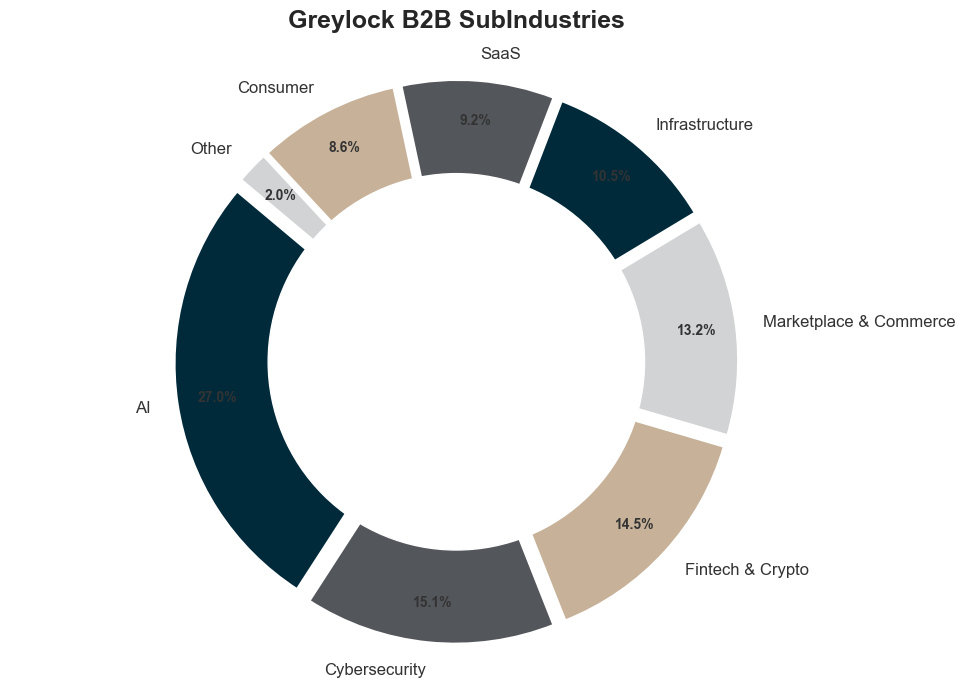

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df['industry'].value_counts() is our data source
yc_temp = yc[yc['industry'] != 'Government']
yc_temp = yc[yc['industry'] == 'B2B']
industry_counts = yc_temp['subindustry'].value_counts()
industry_counts = new_counts


# Set Seaborn aesthetic style and palette
sns.set_theme(style="whitegrid")
# colors = sns.color_palette("")

# Y Combinator Palette
yc_colors = ["#F0652F", "#666666", "#FF6600", "#CCCCCC"]
# sns.set_palette(sns.color_palette(yc_colors))

# Greylock Palette
greylock_colors = ["#002A3A", "#53565A", "#C7B299", "#D1D3D4"]
# sns.set_palette(sns.color_palette(greylock_colors))


# Create the plot
fig, ax = plt.subplots(figsize=(10, 7))

# Plotting the pie chart with aesthetic enhancements
# we explode the slices slightly for a modern look
wedges, texts, autotexts = ax.pie(
    industry_counts, 
    labels=industry_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=greylock_colors,
    pctdistance=0.85, 
    explode=[0.05] * len(industry_counts), 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Create a donut chart by adding a white circle in the middle
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Clean up text for better readability
plt.setp(autotexts, size=10, weight="bold", color="#333333")
plt.setp(texts, size=12, color="#333333")

ax.set_title("Greylock B2B SubIndustries", fontsize=18, fontweight='bold', pad=20)
ax.axis('equal')  # Ensures the pie is drawn as a circle

plt.tight_layout()
plt.savefig('industry_pie_chart.png', dpi=300)

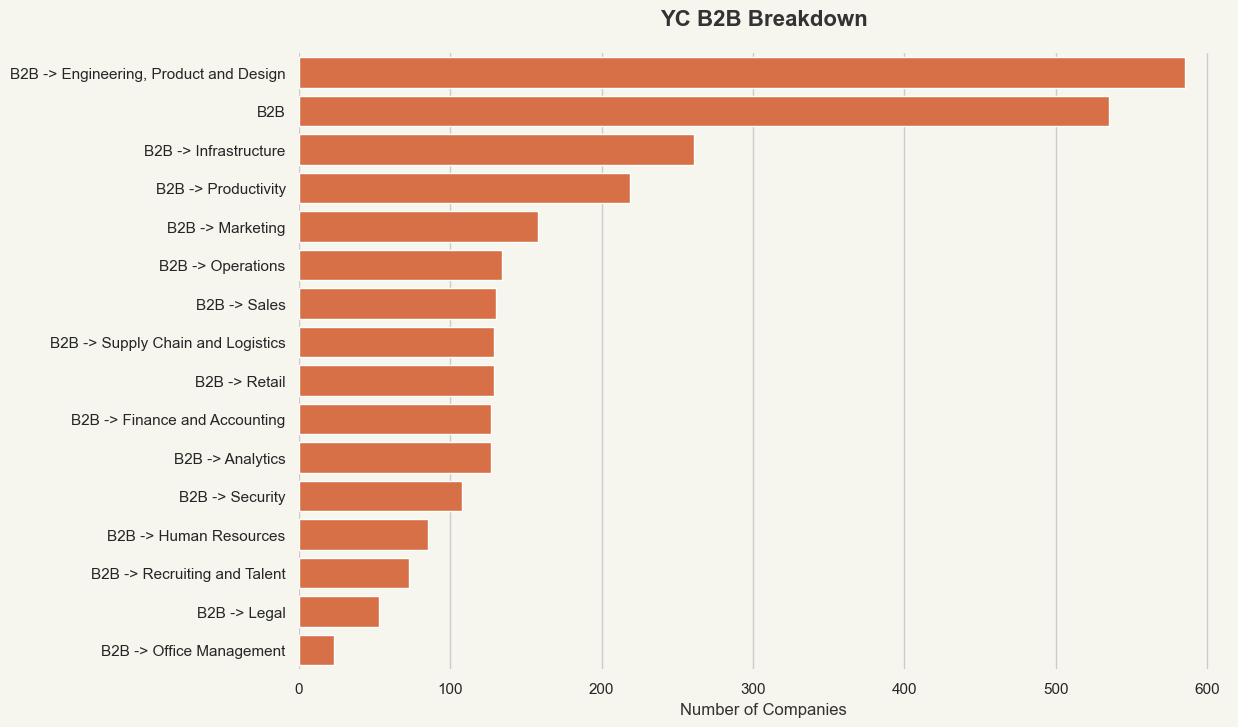

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the aesthetic style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#F6F6EF')
ax.set_facecolor('#F6F6EF')

# 2. Create the bar chart
# order=df['subindustry'].value_counts().index sorts from most to least frequent
sns.countplot(
    data=yc_temp, 
    y='subindustry', 
    order=yc_temp['subindustry'].value_counts().index,
    color='#F0652F',  # YC Orange
    ax=ax
)

# 3. Final Polish
plt.title('YC B2B Breakdown', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Number of Companies', fontsize=12, color='#333333')
plt.ylabel('', fontsize=12) # Removing the label usually looks cleaner for Y-axis categories
sns.despine(left=True, bottom=True)

plt.show()

In [108]:
yc_temp.value_counts("subindustry")

subindustry
B2B -> Engineering, Product and Design    585
B2B                                       535
B2B -> Infrastructure                     261
B2B -> Productivity                       219
B2B -> Marketing                          158
B2B -> Operations                         134
B2B -> Sales                              130
B2B -> Retail                             129
B2B -> Supply Chain and Logistics         129
B2B -> Analytics                          127
B2B -> Finance and Accounting             127
B2B -> Security                           108
B2B -> Human Resources                     85
B2B -> Recruiting and Talent               73
B2B -> Legal                               53
B2B -> Office Management                   23
Name: count, dtype: int64

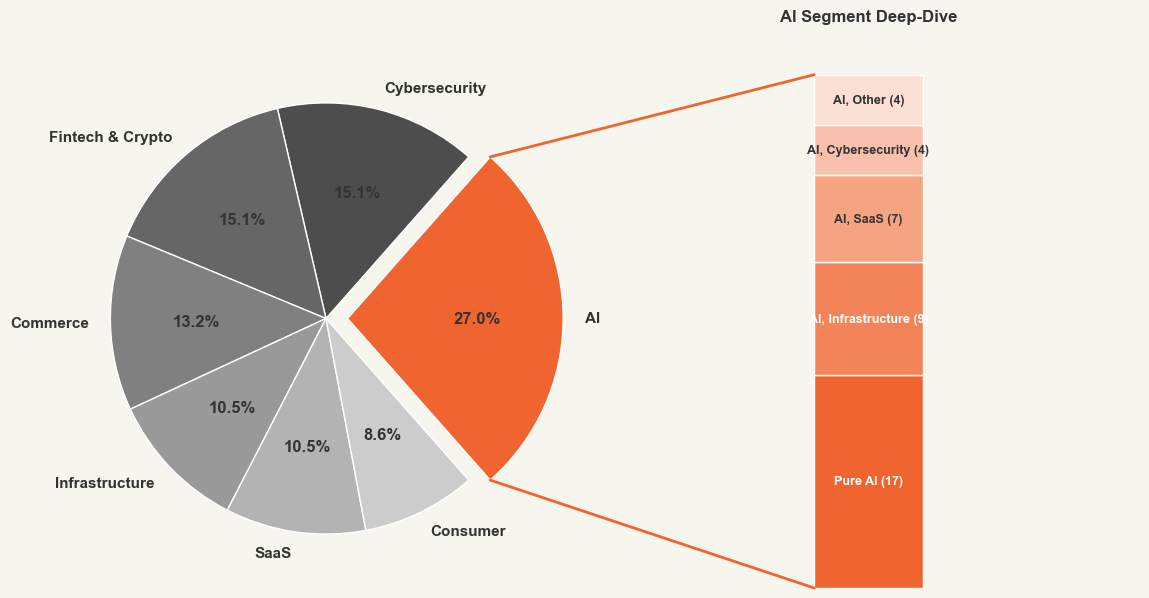

In [91]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import numpy as np

# 1. Main Pie Data (Bucketed to avoid overlap)
labels = ['AI', 'Cybersecurity', 'Fintech & Crypto', 'Commerce', 'Infrastructure', 'SaaS', 'Consumer']
ratios = [41, 23, 23, 20, 16, 16, 13] # Calculated from your multi-label raw counts

# 2. AI Sub-sector Data (The "Bar")
labels_ai = ['Pure AI', 'AI, Infrastructure', 'AI, SaaS', 'AI, Cybersecurity', 'AI, Other']
ratios_ai = [17, 9, 7, 4, 4]
ratios_ai_norm = [x / sum(ratios_ai) for x in ratios_ai]

# Colors: YC Palette
yc_orange, yc_charcoal, yc_linen = "#F0652F", "#333333", "#F6F6EF"
ai_shades = ["#F0652F", "#F38459", "#F6A382", "#F9C1AC", "#FCDFD5"] # Shades for AI segments
other_colors = ["#4D4D4D", "#666666", "#808080", "#999999", "#B3B3B3", "#CCCCCC"]

# 3. Create Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), facecolor=yc_linen)
fig.subplots_adjust(wspace=0)

# 4. Draw Pie
explode = [0.1] + [0]*6 # Explode the AI slice
angle = -180 * (ratios[0]/sum(ratios)) # Align expansion lines
wedges, *_ = ax1.pie(ratios, autopct='%1.1f%%', startangle=angle, labels=labels, 
                     explode=explode, colors=[yc_orange] + other_colors,
                     textprops={'color': yc_charcoal, 'weight': 'bold'})

# 5. Draw Bar
xpos, bottom, width = 0, 0, 0.2
for i, val in enumerate(ratios_ai_norm):
    ax2.bar(xpos, val, width, bottom=bottom, color=ai_shades[i], edgecolor='white')
    ypos = bottom + val / 2
    ax2.text(xpos, ypos, f"{labels_ai[i]} ({ratios_ai[i]})", ha='center', va='center', 
             color='white' if i < 2 else yc_charcoal, fontweight='bold', fontsize=9)
    bottom += val

ax2.set_title('AI Segment Deep-Dive', color=yc_charcoal, fontweight='bold', pad=20)
ax2.axis('off')
ax2.set_xlim(-2.5 * width, 2.5 * width)

# 6. Draw Connection Lines
theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center, r = wedges[0].center, wedges[0].r
for y_bar, theta in zip([1, 0], [theta2, theta1]):
    x = r * np.cos(np.pi / 180 * theta) + center[0]
    y = r * np.sin(np.pi / 180 * theta) + center[1]
    con = ConnectionPatch(xyA=(-width/2, y_bar), coordsA=ax2.transData, xyB=(x, y), coordsB=ax1.transData)
    con.set_color(yc_orange); con.set_linewidth(2)
    ax2.add_artist(con)

plt.show()

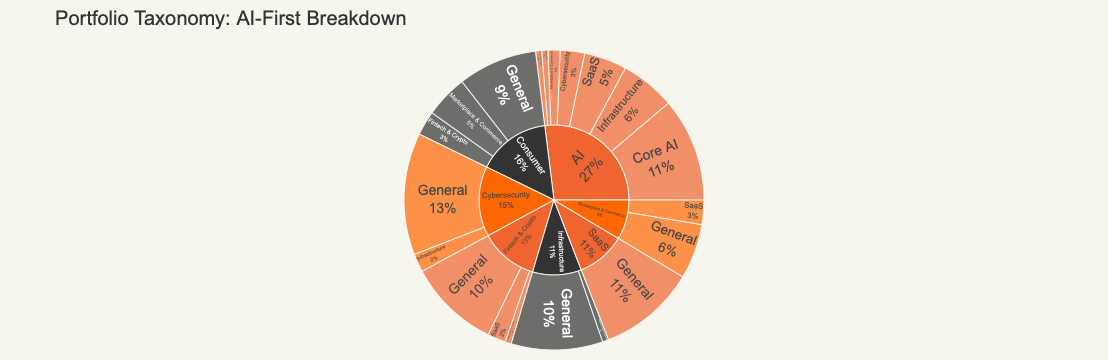

In [81]:
import pandas as pd
import plotly.express as px

# 1. Input Raw Data Counts
data_dict = {
    "Cybersecurity": 20, "AI": 17, "SaaS": 16, "Fintech & Crypto": 15,
    "Infrastructure": 15, "Consumer": 13, "AI, Infrastructure": 9,
    "Marketplace & Commerce": 9, "AI, SaaS": 7, "Consumer, Marketplace & Commerce": 6,
    "Consumer, Fintech & Crypto": 4, "Marketplace & Commerce, SaaS": 4,
    "AI, Cybersecurity": 4, "Cybersecurity, Infrastructure": 3,
    "Fintech & Crypto, SaaS": 3, "AI, Marketplace & Commerce": 2,
    "Infrastructure, Marketplace & Commerce, SaaS": 1, "AI, Fintech & Crypto": 1,
    "Fintech & Crypto, Marketplace & Commerce": 1, "AI, Consumer": 1,
    "Consumer, Marketplace & Commerce, SaaS": 1
}

# 2. Convert raw counts to individual rows for processing
expanded_data = []
for labels, count in data_dict.items():
    for _ in range(count):
        expanded_data.append(labels)
df = pd.DataFrame(expanded_data, columns=['domain_string'])

# 3. Create Sunburst Hierarchy Logic (Prioritizing 'AI')
def flatten_to_sunburst(entry_string):
    """
    Takes a string like 'AI, Infrastructure' and returns ONE level hierarchy
    formatted [Parent, Secondary Sector], prioritized by AI.
    """
    # Split the multi-labels into individual tags
    tags = [i.strip() for i in entry_string.split(',')]
    primary = "Other Sectors"
    secondary = "General"
    
    # Priority handling to create the 'AI Bucket'
    if 'AI' in tags:
        primary = 'AI'
        # Assign the other tag as the sector
        remaining = [t for t in tags if t != 'AI']
        if remaining:
            secondary = remaining[0] # Take the next tag as sector
        else:
            secondary = "Core AI" # Only 'AI' tag
    else:
        # If no AI, take the first available sector as primary
        if tags:
            primary = tags[0]
            if len(tags) > 1:
                secondary = tags[1]
                
    return [primary, secondary]

# Apply the hierarchy logic to create columns for Plotly
df['levels'] = df['domain_string'].apply(flatten_to_sunburst)
df['Parent Sector'] = df['levels'].apply(lambda x: x[0])
df['Secondary Sector'] = df['levels'].apply(lambda x: x[1])

# Aggregate the data back to counts for the chart
df_counts = df.groupby(['Parent Sector', 'Secondary Sector']).size().reset_index(name='Count')

# 4. Generate Plot with YC Aesthetic
yc_colors = ["#F0652F", "#333333", "#FF6600"] # Orange, Charcoal, HN Orange

fig = px.sunburst(
    df_counts, 
    path=['Parent Sector', 'Secondary Sector'], # Define the hierarchy path
    values='Count',
    color='Parent Sector', # Color by parent category
    color_discrete_sequence=yc_colors, # Apply YC colors
    title='Portfolio Taxonomy: AI-First Breakdown'
)

# Customize the chart layout for aesthetics
fig.update_layout(
    margin=dict(t=50, l=10, r=10, b=10),
    paper_bgcolor='#F6F6EF', # Set YC Linen background
    font=dict(family="Arial", size=14, color="#333333")
)

# Configure the labels (Percentage of whole / percentage of parent)
fig.update_traces(
    textinfo="label+percent entry",
    insidetextorientation='radial'
)

# Show the interactive plot
fig.show()

In [38]:
yc[yc['website'].isna()]#.value_counts("status")
# greylock[greylock['website'].isna()]
# yc[yc['name'].str.contains("Crew")]

,slug,name,batch,status,industry,subindustry,one_liner,team_size,stage,top_company,...,hn_points,hn_comments,total_funding_usd,last_funding_round,acquired_by,ipo_date,is_dead,website,yc_url,founders
457,flightcaster,Flightcaster,Summer 2009,Acquired,Consumer,"Consumer -> Travel, Leisure and Tourism",NaN,2.0,Early,0,...,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ycombinator.com/companies/flightca...,NaN
474,tuxebo,Tuxebo,Summer 2009,Inactive,Real Estate and Construction,Real Estate and Construction,Tuxebo was a platform for renting things,0.0,Early,0,...,131.0,38.0,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ycombinator.com/companies/tuxebo,NaN
628,partnered,Partnered,Summer 2012,Inactive,B2B,B2B -> Sales,Partnered is a digital platform automating bus...,11.0,Early,0,...,401.0,157.0,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ycombinator.com/companies/partnered,NaN
769,sliced-investing,Sliced Investing,Summer 2014,Acquired,Fintech,Fintech -> Asset Management,Crowdfunding for hedge funds,11.0,Early,0,...,166.0,113.0,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ycombinator.com/companies/sliced-i...,NaN
982,utilityscore,UtilityScore (formerly Pando),Summer 2016,Inactive,Consumer,Consumer -> Home and Personal,API that estimates utility costs for 100M+ homes.,6.0,Early,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ycombinator.com/companies/utilitys...,NaN
1074,prism-labs,Prism Labs,Summer 2017,Inactive,Consumer,Consumer -> Job and Career Services,NaN,5.0,Early,0,...,40.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ycombinator.com/companies/prism-labs,NaN
1392,symplex,Symplex,Summer 2019,Acquired,B2B,B2B,Applied Reinforcement Learning Research Labora...,8.0,Early,0,...,115.0,73.0,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ycombinator.com/companies/symplex,NaN
1519,liyfe,Liyfe,Summer 2020,Active,Healthcare,Healthcare,Digital Nurse to Automate Symptom Assessment a...,2.0,Early,0,...,70.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ycombinator.com/companies/liyfe,NaN
1549,openbase,Openbase,Summer 2020,Inactive,B2B,"B2B -> Engineering, Product and Design",Open-source library discovery,0.0,Early,0,...,148.0,85.0,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ycombinator.com/companies/openbase,NaN
1621,workbase,Workbase,Summer 2020,Acquired,B2B,B2B -> Productivity,Data & workflow platform for B2B account teams,NaN,Early,0,...,29.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,https://www.ycombinator.com/companies/workbase,NaN


In [93]:
greylock = pd.read_csv("../data-collection/greylock_portfolio.csv")
greylock[greylock['name'].str.contains("aspo")]

,name,tagline,description,website,domain,first_partnered,status,investors,leadership,hq
12,aspora,Transforming banking for the Global Diaspora,Aspora is building banking solutions for immig...,https://www.aspora.com/,Fintech & Crypto,Series A,Active,"Asheem Chandna, Jason Risch, Seth Rosenberg","Parth Garg, CEO & Founder",London


In [59]:
yc = pd.read_csv("../data-collection/archive_1/yc_companies.csv")
yc[yc['name'].str.contains('greenl')]

,slug,name,batch,status,industry,subindustry,one_liner,team_size,stage,top_company,...,hn_points,hn_comments,total_funding_usd,last_funding_round,acquired_by,ipo_date,is_dead,website,yc_url,founders


In [43]:
import pandas as pd
import re

# 1. Load your data
greylock = pd.read_csv("../data-collection/greylock_portfolio.csv")
yc = pd.read_csv("../data-collection/archive_1/yc_companies.csv")

# 2. Define the cleaning pattern 
# This looks for http://, https://, and www. at the start of the string
pattern = r'^https?://(?:www\.)?'

def clean_url(df, column='website'):
    return (df[column]
            .fillna('')                  # Handle potential NaNs
            .str.lower()                 # Case-insensitivity
            .str.strip()                 # Remove accidental whitespace
            .str.replace(pattern, '', regex=True) # Strip http/https/www
            .str.rstrip('/'))            # Remove trailing slashes (e.g., 'site.com/' -> 'site.com')

# 3. Apply the cleaning to both dataframes
greylock['website_clean'] = clean_url(greylock)
yc['website_clean'] = clean_url(yc)

# 4. Filter out empty websites to prevent "false matches" on blanks
greylock = greylock[greylock['website_clean'] != '']
yc = yc[yc['website_clean'] != '']

# 5. Deduplicate (Crucial step based on your previous error!)
greylock = greylock.drop_duplicates(subset='website_clean')
yc = yc.drop_duplicates(subset='website_clean')

# 6. Merge on the cleaned column
merge = pd.merge(greylock, yc, on='website_clean', how='inner')

print(f"Total matches found: {len(merge)}")

Total matches found: 13


In [92]:
list(merge['name_x'])#.value_counts("subindustry")

['airbnb',
 'aspora',
 'coinbase',
 'docker',
 'dropbox',
 'gem',
 'instawork',
 'postscript',
 'ramp',
 'sqreen',
 'tydo',
 'validere',
 'vori']